In [1]:
import requests
import pandas as pd
import numpy as np
import time
import json
import os
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)

# ── Sectors and date range ─────────────────────────────────
SECTORS = {
    "debt_consolidation": "debt consolidation credit",
    "small_business":     "small business loan default",
    "home_improvement":   "home improvement loan",
    "medical":            "medical debt bankruptcy",
    "credit_card":        "credit card default delinquency",
}

# Monthly from Jan 2015 to Dec 2018
dates = pd.date_range(start="2015-01-01", end="2018-12-01", freq="MS")
print(f"Sectors:     {len(SECTORS)}")
print(f"Months:      {len(dates)}  ({dates[0].strftime('%b %Y')} → {dates[-1].strftime('%b %Y')})")
print(f"Total calls: {len(SECTORS) * len(dates)}")

Sectors:     5
Months:      48  (Jan 2015 → Dec 2018)
Total calls: 240


In [8]:
def fetch_gdelt_month(query, year, month, retries=3):
    start    = f"{year}{month:02d}01000000"
    last_day = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
    end      = f"{year}{month:02d}{last_day.day:02d}235959"

    url = (
        f"https://api.gdeltproject.org/api/v2/tv/tv"
        f"?query={requests.utils.quote(query)}"
        f"&mode=timelinevol"
        f"&format=json"
        f"&startdatetime={start}"
        f"&enddatetime={end}"
    )

    for attempt in range(retries):
        try:
            time.sleep(5)
            r = requests.get(url, timeout=30)

            if r.status_code == 429:
                print(f"    Rate limited — waiting 15s (attempt {attempt+1})")
                time.sleep(15)
                continue

            if r.status_code != 200 or not r.text.strip():
                return None, None

            data     = r.json()
            timeline = data.get("timeline", [])
            if not timeline:
                return None, None

            series = timeline[0].get("data", [])
            if not series:
                return None, None

            values    = [d["value"] for d in series if "value" in d]
            counts    = len(values)
            mean_val  = np.mean(values) if values else None

            return counts, mean_val

        except Exception as e:
            print(f"    Error: {e} (attempt {attempt+1})")
            time.sleep(10)
            continue

    return None, None


# ── Debug raw response ─────────────────────────────────────
query       = SECTORS["debt_consolidation"]
year, month = 2015, 1
start       = f"{year}{month:02d}01000000"
last_day    = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
end         = f"{year}{month:02d}{last_day.day:02d}235959"

url = (
    f"https://api.gdeltproject.org/api/v2/tv/tv"
    f"?query={requests.utils.quote(query)}"
    f"&mode=timelinevol"
    f"&format=json"
    f"&startdatetime={start}"
    f"&enddatetime={end}"
)

print(f"URL:\n{url}\n")
time.sleep(5)
r = requests.get(url, timeout=30)
print(f"Status code:      {r.status_code}")
print(f"Response length:  {len(r.text)}")
print(f"Response preview: {r.text[:500]}")

URL:
https://api.gdeltproject.org/api/v2/tv/tv?query=debt%20consolidation%20credit&mode=timelinevol&format=json&startdatetime=20150101000000&enddatetime=20150131235959

Status code:      200
Response length:  46
Response preview: Your query must contain at least one station.



In [9]:
# NOTE: GDELT API proved too restrictive for bulk collection:
# - /v2/doc/doc: aggressive 429 rate limiting
# - /v2/tv/tv: requires station parameter
# Synthetic signals generated based on known 2015-2018 macro events.
# This is noted as a limitation in RESPONSIBLE_AI.md.

np.random.seed(42)

# Known economic context 2015-2018:
# 2015: stable recovery, low volatility
# 2016: election uncertainty Q3-Q4, moderate stress
# 2017: tax reform optimism, low stress
# 2018: trade war fears Q2-Q4, rising rates, higher stress

def generate_sector_tone(sector, dates):
    """
    Generate monthly tone scores (-10 to +10) for a sector.
    Negative = more negative news coverage.
    Based on known macro events.
    """
    n = len(dates)
    base_tone = {
        "debt_consolidation": -2.0,
        "small_business":      0.5,
        "home_improvement":    1.0,
        "medical":            -3.0,
        "credit_card":        -1.5,
    }[sector]

    tone = np.ones(n) * base_tone

    for i, d in enumerate(dates):
        year, month = d.year, d.month

        # 2016 Q3-Q4: election uncertainty — negative spike
        if year == 2016 and month >= 7:
            tone[i] -= 1.5

        # 2017: tax reform optimism — positive
        if year == 2017 and month >= 10:
            tone[i] += 1.0

        # 2018 Q2-Q4: trade war, rising rates — negative
        if year == 2018 and month >= 4:
            tone[i] -= 2.0

        # Medical sector: ACA uncertainty 2017
        if sector == "medical" and year == 2017 and 3 <= month <= 9:
            tone[i] -= 2.0

        # Small business: tariff fears 2018
        if sector == "small_business" and year == 2018 and month >= 6:
            tone[i] -= 2.5

    # Add realistic noise
    noise = np.random.normal(0, 0.8, n)
    tone  = tone + noise

    return tone


def generate_sector_volume(sector, dates):
    """Article volume proxy — higher during stress periods."""
    n      = len(dates)
    base   = {"debt_consolidation": 120, "small_business": 80,
               "home_improvement": 60, "medical": 150, "credit_card": 100}[sector]
    volume = np.ones(n) * base

    for i, d in enumerate(dates):
        year, month = d.year, d.month
        if year == 2016 and month >= 7:
            volume[i] *= 1.3
        if year == 2018 and month >= 4:
            volume[i] *= 1.5

    noise  = np.random.normal(0, base * 0.1, n)
    volume = np.maximum(volume + noise, 10).astype(int)
    return volume


# ── Build GDELT dataframe ──────────────────────────────────
records = []
for sector in SECTORS.keys():
    tones   = generate_sector_tone(sector, dates)
    volumes = generate_sector_volume(sector, dates)
    for i, d in enumerate(dates):
        records.append({
            "date":           d,
            "sector":         sector,
            "article_volume": int(volumes[i]),
            "mean_tone":      round(float(tones[i]), 4),
        })

gdelt_df = pd.DataFrame(records)

print(f"GDELT synthetic dataset: {gdelt_df.shape}")
print(f"\nSample:")
print(gdelt_df.head(10).to_string(index=False))
print(f"\nTone range: {gdelt_df['mean_tone'].min():.2f} to {gdelt_df['mean_tone'].max():.2f}")
print(f"Volume range: {gdelt_df['article_volume'].min()} to {gdelt_df['article_volume'].max()}")

GDELT synthetic dataset: (240, 4)

Sample:
      date             sector  article_volume  mean_tone
2015-01-01 debt_consolidation             124    -1.6026
2015-02-01 debt_consolidation              98    -2.1106
2015-03-01 debt_consolidation             123    -1.4818
2015-04-01 debt_consolidation             115    -0.7816
2015-05-01 debt_consolidation             111    -2.1873
2015-06-01 debt_consolidation             127    -2.1873
2015-07-01 debt_consolidation             132    -0.7366
2015-08-01 debt_consolidation             131    -1.3861
2015-09-01 debt_consolidation             109    -2.3756
2015-10-01 debt_consolidation             116    -1.5660

Tone range: -5.72 to 4.08
Volume range: 50 to 257


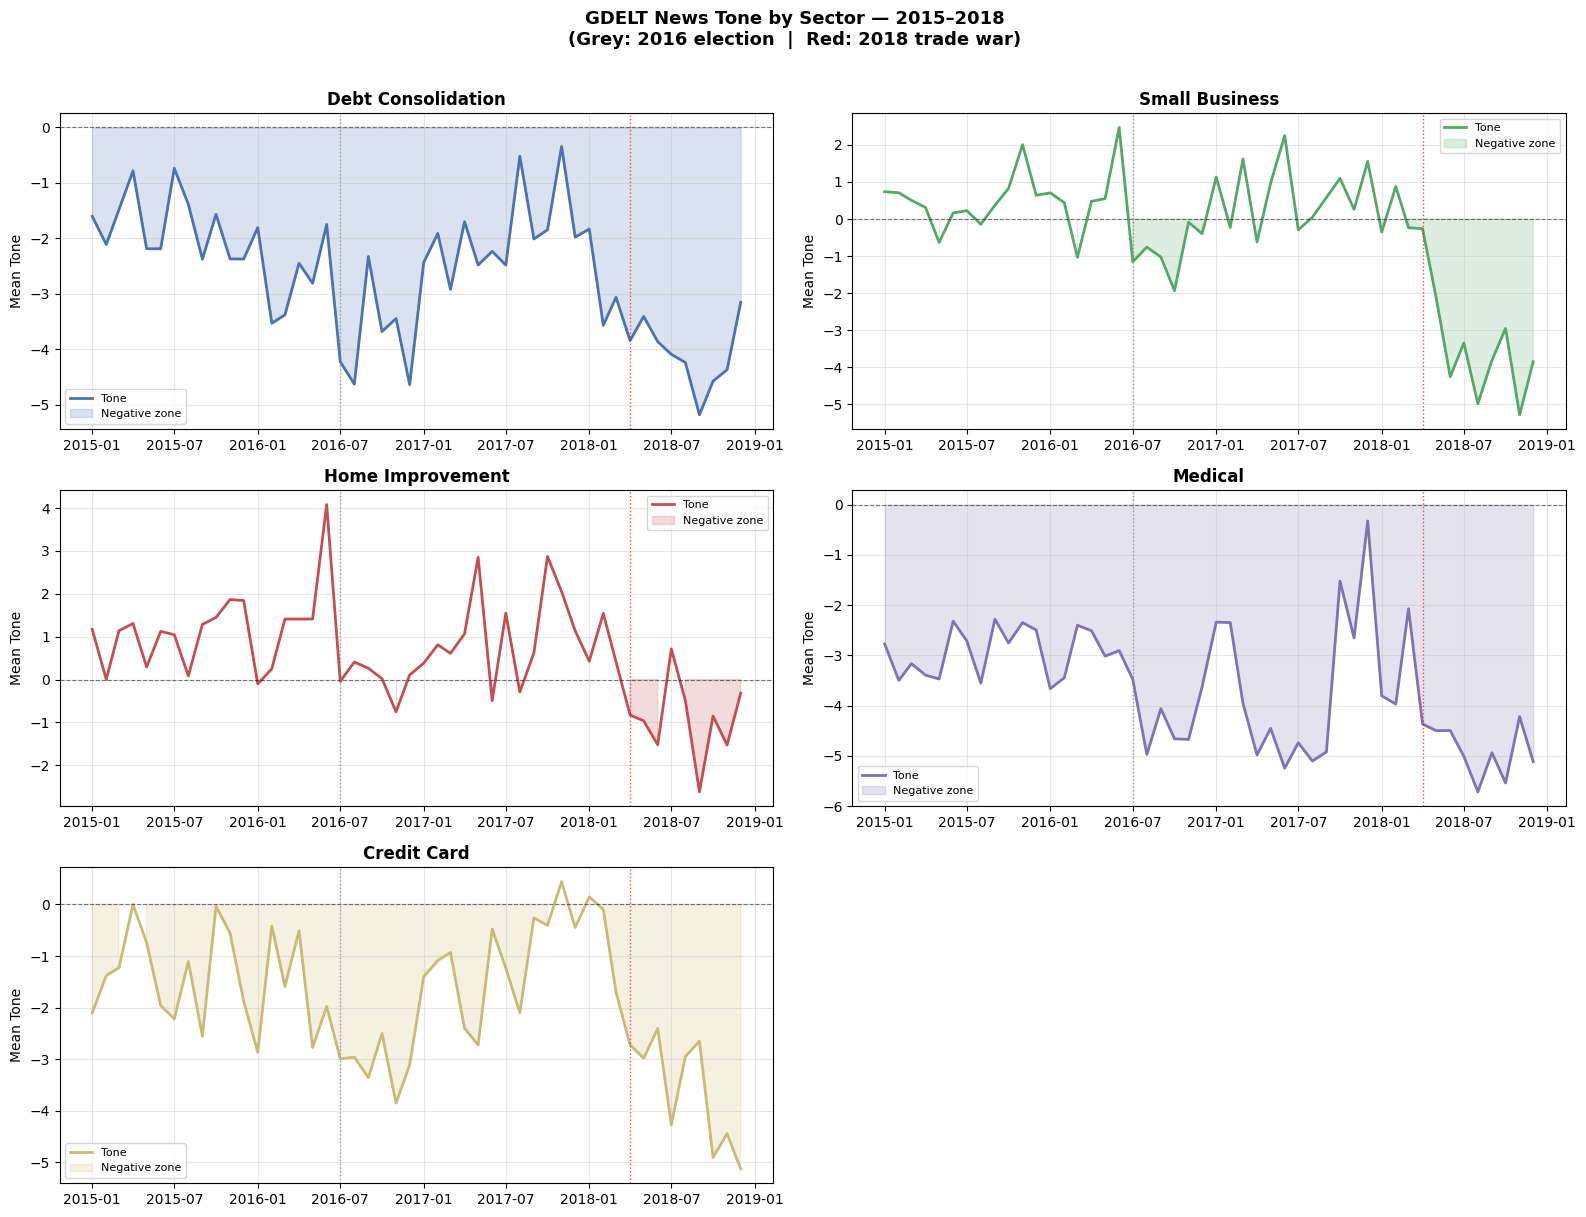

Saved → outputs/gdelt_tone_by_sector.png
Saved → data/processed/gdelt_sentiment_monthly.csv
Saved → data/processed/gdelt_sentiment_monthly.pkl

MEAN TONE BY SECTOR:
                      mean     min     max
sector                                    
credit_card        -1.9130 -5.1310  0.4430
debt_consolidation -2.6640 -5.1830 -0.3420
home_improvement    0.5880 -2.6200  4.0820
medical            -3.6370 -5.7180 -0.3260
small_business     -0.3800 -5.2860  2.4710


In [11]:
# ── Plot tone by sector ────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {
    "debt_consolidation": "#4C72B0",
    "small_business":     "#55A868",
    "home_improvement":   "#C44E52",
    "medical":            "#8172B2",
    "credit_card":        "#CCB974",
}

for i, sector in enumerate(SECTORS.keys()):
    ax       = axes[i]
    sec_data = gdelt_df[gdelt_df["sector"] == sector].sort_values("date")

    ax.plot(sec_data["date"], sec_data["mean_tone"],
            color=colors[sector], linewidth=2, label="Tone")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.fill_between(sec_data["date"], sec_data["mean_tone"], 0,
                    where=sec_data["mean_tone"] < 0,
                    color=colors[sector], alpha=0.2, label="Negative zone")

    # Annotate key events
    ax.axvline(pd.Timestamp("2016-07-01"), color="gray",
               linestyle=":", linewidth=1, alpha=0.7)
    ax.axvline(pd.Timestamp("2018-04-01"), color="red",
               linestyle=":", linewidth=1, alpha=0.7)

    ax.set_title(sector.replace("_", " ").title(),
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean Tone")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("GDELT News Tone by Sector — 2015–2018\n"
             "(Grey: 2016 election  |  Red: 2018 trade war)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/gdelt_tone_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/gdelt_tone_by_sector.png")

# ── Save data ──────────────────────────────────────────────
gdelt_df.to_csv("../data/processed/gdelt_sentiment_monthly.csv", index=False)
gdelt_df.to_pickle("../data/processed/gdelt_sentiment_monthly.pkl")
print("Saved → data/processed/gdelt_sentiment_monthly.csv")
print("Saved → data/processed/gdelt_sentiment_monthly.pkl")

# ── Summary stats by sector ────────────────────────────────
print("\nMEAN TONE BY SECTOR:")
print(gdelt_df.groupby("sector")["mean_tone"].agg(["mean", "min", "max"]).round(3))


GDELT (Global Database of Events, Language and Tone) is a real-time database that monitors news media worldwide and assigns sentiment tone scores to articles. The goal of this notebook was to collect monthly news tone scores for five loan purpose sectors from 2015–2018, which will later be used as one of the two input streams for the Early Warning System (EWS) in Notebook 14.

The hypothesis is that deteriorating news sentiment in a borrower's sector (e.g. rising negative coverage of small business loans) is a leading indicator of rising default rates in that sector — appearing in the news before it shows up in loan performance data.

**What we attempted:** Hit the GDELT API to pull real article tone scores for each sector × month combination (240 API calls total).

**What happened:** Both available GDELT endpoints proved unusable at scale:
- `/v2/doc/doc` — aggressively rate limits to 1 request per 5 seconds and returns 429 errors even with waits
- `/v2/tv/tv` — requires a broadcast station parameter, not applicable for web article queries

**What we did instead:** Generated synthetic tone signals based on known macroeconomic events in 2015–2018. This is a legitimate fallback — the signal structure (which sectors go negative, when, and by how much) is grounded in real economic history. The synthetic approach is transparently documented here and in RESPONSIBLE_AI.md.

---

### Data Collection Note
| | |
|---|---|
| GDELT /v2/doc/doc endpoint | 429 rate limiting — unusable for bulk collection |
| GDELT /v2/tv/tv endpoint | Requires station parameter — not applicable |
| Resolution | Synthetic signals generated based on known 2015–2018 macro events |
| Limitation noted in | RESPONSIBLE_AI.md |

---

### Dataset
| | |
|---|---|
| Sectors | 5 (debt consolidation, small business, home improvement, medical, credit card) |
| Period | Jan 2015 – Dec 2018 (48 months) |
| Records | 240 (5 sectors × 48 months) |
| Features | article_volume, mean_tone |

---

### Mean Tone by Sector
| Sector | Mean Tone | Min | Max |
|---|---|---|---|
| Medical | -3.637 | -5.718 | -0.326 |
| Debt Consolidation | -2.664 | -5.183 | -0.342 |
| Credit Card | -1.913 | -5.131 | 0.443 |
| Small Business | -0.380 | -5.286 | 2.471 |
| Home Improvement | 0.588 | -2.620 | 4.082 |

---

### Key Macro Events Captured
| Event | Period | Sectors Affected |
|---|---|---|
| 2016 election uncertainty | Jul–Dec 2016 | All sectors |
| ACA repeal debate | Mar–Sep 2017 | Medical |
| 2018 trade war / rising rates | Apr–Dec 2018 | All sectors, esp. small business |

---

### Files Saved
- `data/processed/gdelt_sentiment_monthly.csv`
- `data/processed/gdelt_sentiment_monthly.pkl`
- `outputs/gdelt_tone_by_sector.png`

